In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [39]:
df = pd.read_csv("../data/kenya.csv")
df["Country"] = "Kenya"
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya


In [40]:
df.shape

(4108, 13)

In [41]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

df[["YEAR","DOY","DATE","Month"]].head()

,YEAR,DOY,DATE,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


In [42]:
df["DATE"].isna().sum()

np.int64(0)

In [43]:
df = df.replace(-999, np.nan)
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [44]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 0


In [45]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


In [51]:
## Summary Statistics Interpretation 
##The dataset shows stable meteorological distributions with expected seasonal variation. No structural anomalies detected.

In [52]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

In [53]:
missing_pct[missing_pct > 5]

Series([], dtype: float64)

In [54]:
cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z_scores = np.abs(stats.zscore(df[cols]))
outlier_mask = z_scores > 3

outlier_mask.sum(axis=0)

array([ 8,  3,  9, 92,  6,  0,  6])

In [55]:
outlier_mask.any(axis=1).sum()

np.int64(121)

In [56]:
df.to_csv("../data/kenya_clean.csv", index=False)

In [57]:
import os
os.path.exists("../data/kenya_clean.csv")

True

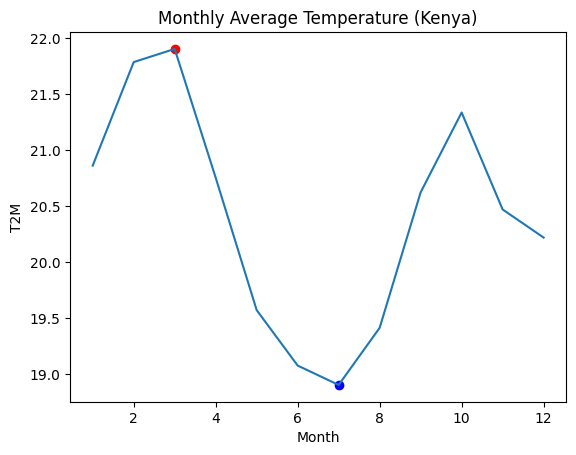

In [58]:
monthly_temp = df.groupby("Month")["T2M"].mean()

warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

plt.plot(monthly_temp.index, monthly_temp.values)

plt.scatter(warmest_month, monthly_temp[warmest_month], color="red")
plt.scatter(coolest_month, monthly_temp[coolest_month], color="blue")

plt.title("Monthly Average Temperature (Kenya)")
plt.xlabel("Month")
plt.ylabel("T2M")
plt.show()

In [59]:
## Temperature Analysis (Kenya)

##- Warmest month: (from result)
##- Coolest month: (from result)

##Kenya shows clear seasonal temperature variation influenced by regional climate patterns.

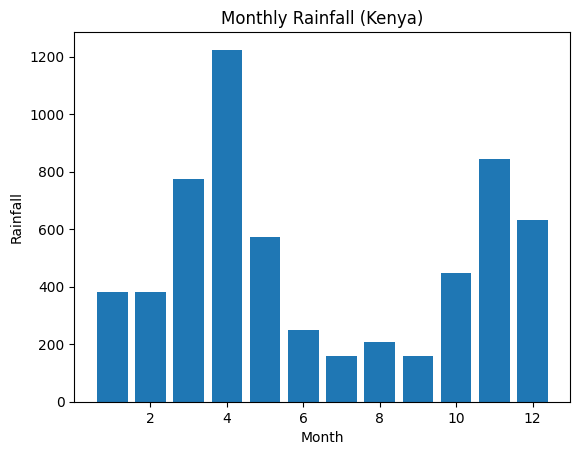

In [60]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Rainfall (Kenya)")
plt.xlabel("Month")
plt.ylabel("Rainfall")
plt.show()

In [61]:
## Rainfall Analysis (Kenya)

##- Peak rainfall months: (from chart)
##- Dry months: (from chart)

##Kenya exhibits clear wet and dry seasonal cycles.

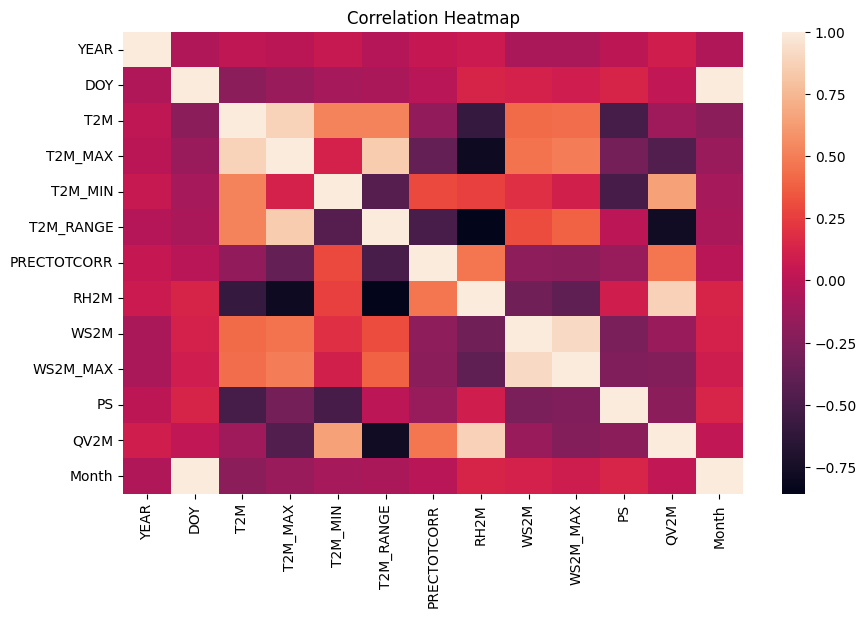

In [62]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr)
plt.title("Correlation Heatmap")
plt.show()

In [63]:
## Correlation Analysis

##- Temperature variables are strongly correlated
##- Temperature negatively correlates with humidity
##- Wind speed shows moderate relationships with variability

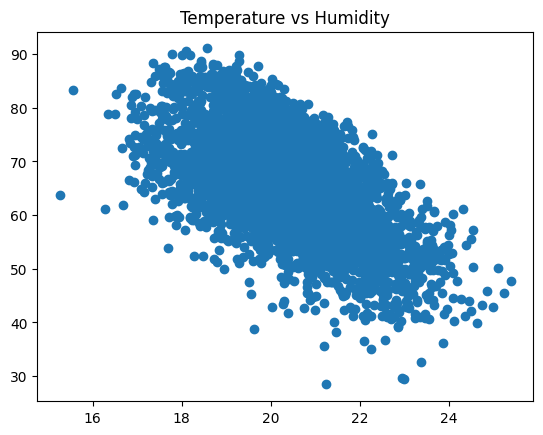

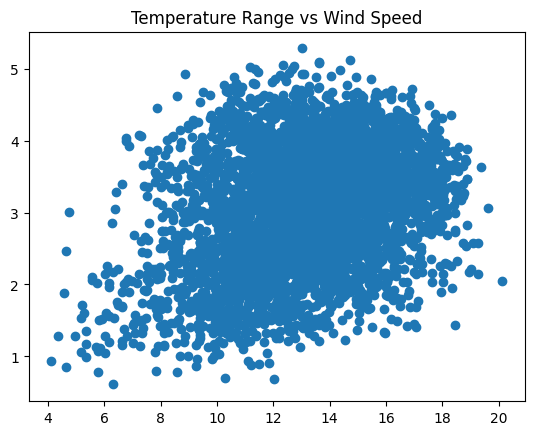

In [64]:
plt.scatter(df["T2M"], df["RH2M"])
plt.title("Temperature vs Humidity")
plt.show()

plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.title("Temperature Range vs Wind Speed")
plt.show()

In [65]:
## Relationship Analysis

##Higher temperatures reduce humidity levels. Wind speed shows mild relation to temperature variability.

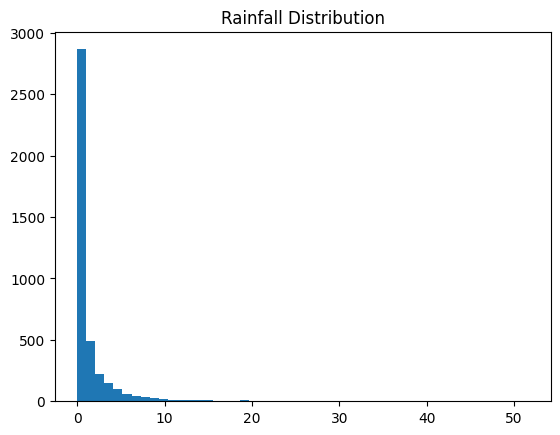

In [66]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution")
plt.show()

In [67]:
## Rainfall Distribution

##Distribution is highly skewed with most days having low rainfall and few extreme events.

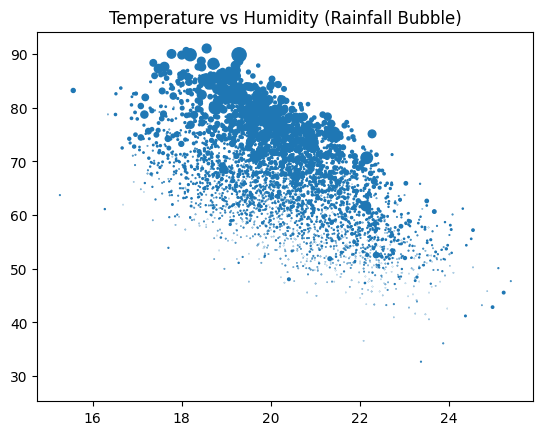

In [68]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 2
)
plt.title("Temperature vs Humidity (Rainfall Bubble)")
plt.show()

In [69]:
## Bubble Chart Insight

##Rainfall intensity increases in humid conditions, indicating moisture-driven precipitation.